<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_neural-network-using-numpy-keras-pytorch/blob/main/colab_a_numpy_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab A — 3-Layer Neural Network: NumPy from Scratch

**Assignment:** Non-linear regression using a 3-layer deep neural network built **entirely from scratch** using NumPy (plus `tf.einsum` for matrix operations).  
**Key concepts:** Manual forward pass, manual backpropagation, chain rule gradient propagation, 3-variable synthetic data, 4D visualization.

---

## Architecture Overview
```
Input (3) → Hidden Layer 1 (64, ReLU) → Hidden Layer 2 (32, ReLU) → Output (1, Linear)
```
- **No** automatic differentiation — every gradient is computed by hand
- **tf.einsum** replaces all matrix multiplications
- **3-variable nonlinear equation:** `y = sin(x1) * cos(x2) + x3² + 0.5*sin(x1*x3)`

In [1]:
# ─────────────────────────────────────────────
# SECTION 1: Imports
# ─────────────────────────────────────────────
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.19.0
NumPy version: 2.0.2


## Section 2: Synthetic Data Generation

We define a **3-variable nonlinear equation** and generate synthetic training data.  
The target function deliberately contains interactions between variables (making it non-trivially nonlinear):

$$y = \sin(x_1) \cdot \cos(x_2) + x_3^2 + 0.5 \cdot \sin(x_1 \cdot x_3) + \epsilon$$

In [2]:
# ─────────────────────────────────────────────
# SECTION 2: Synthetic Data Generation
# ─────────────────────────────────────────────

def generate_data(n_samples=2000):
    """Generate 3-variable nonlinear regression data.

    Equation: y = sin(x1)*cos(x2) + x3^2 + 0.5*sin(x1*x3) + noise

    This creates a complex nonlinear surface that:
    - Cannot be captured by a linear model
    - Has cross-variable interaction terms (x1*x3)
    - Requires at least 2 hidden layers to approximate well
    """
    x1 = np.random.uniform(-np.pi, np.pi, n_samples)
    x2 = np.random.uniform(-np.pi, np.pi, n_samples)
    x3 = np.random.uniform(-2, 2, n_samples)

    noise = np.random.normal(0, 0.05, n_samples)  # small noise
    y = np.sin(x1) * np.cos(x2) + x3**2 + 0.5 * np.sin(x1 * x3) + noise

    X = np.stack([x1, x2, x3], axis=1)  # shape: (n_samples, 3)
    y = y.reshape(-1, 1)                 # shape: (n_samples, 1)
    return X, y

X, y = generate_data(n_samples=2000)

# ── Normalize inputs and outputs ──────────────
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
y_mean, y_std = y.mean(), y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# ── Train/test split ──────────────────────────
split = int(0.8 * len(X))
X_train, X_test = X_norm[:split], X_norm[split:]
y_train, y_test = y_norm[:split], y_norm[split:]

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Input shape      : {X_train.shape}   (n_samples × 3 features)')
print(f'Output shape     : {y_train.shape}  (n_samples × 1 target)')
print(f'y range          : [{y.min():.3f}, {y.max():.3f}]')

Training samples : 1600
Test samples     : 400
Input shape      : (1600, 3)   (n_samples × 3 features)
Output shape     : (1600, 1)  (n_samples × 1 target)
y range          : [-1.172, 5.159]


## Section 3: 4D Visualization

Since we have 3 input features (x1, x2, x3) + 1 output (y), we use **PCA** to reduce inputs to 2D for a 3D plot, using **color** as the 4th dimension (representing y values).

PCA explained variance ratio: [0.3458614  0.33235369]
Total variance explained: 0.678


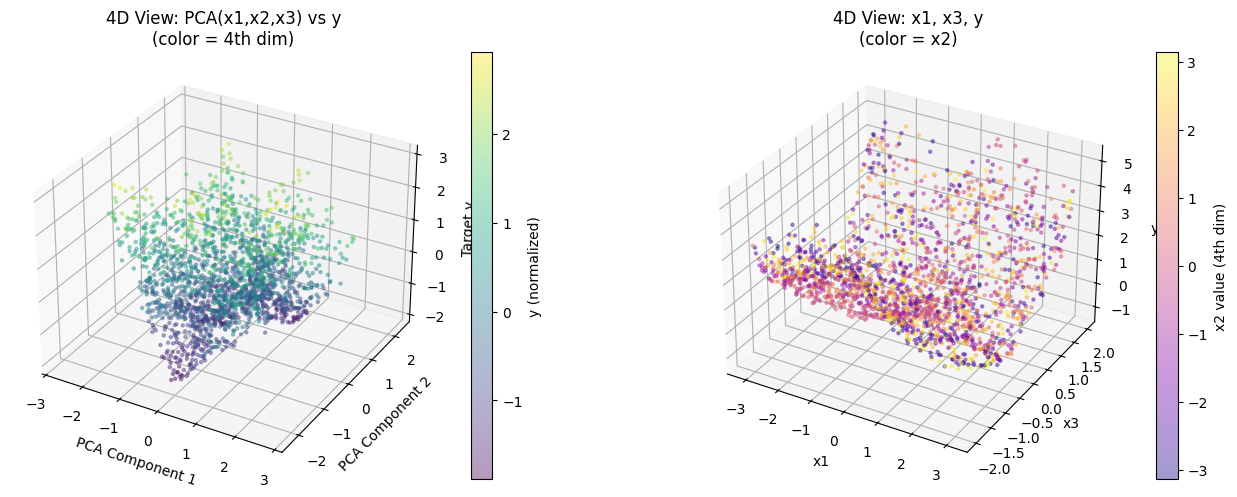

Saved: 4d_visualization.png


In [3]:
# ─────────────────────────────────────────────
# SECTION 3: 4D Visualization using PCA
# ─────────────────────────────────────────────

# PCA: reduce 3D input space → 2D for plotting
# (dimensionality reduction trick as hinted in assignment)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_norm)

print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')

fig = plt.figure(figsize=(14, 5))

# ── Plot 1: 4D plot (PCA-1, PCA-2, y, color=y) ──
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(
    X_2d[:, 0],      # PCA component 1 (x-axis)
    X_2d[:, 1],      # PCA component 2 (y-axis)
    y_norm.ravel(),  # target value (z-axis)
    c=y_norm.ravel(),# color = 4th dimension
    cmap='viridis',
    alpha=0.4,
    s=5
)
plt.colorbar(scatter, ax=ax1, label='y (normalized)')
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.set_zlabel('Target y')
ax1.set_title('4D View: PCA(x1,x2,x3) vs y\n(color = 4th dim)')

# ── Plot 2: Direct x1 vs x3 vs y slice ──────────
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    X[:, 0],         # x1 original
    X[:, 2],         # x3 original
    y.ravel(),
    c=X[:, 1],       # color = x2 (4th dim)
    cmap='plasma',
    alpha=0.4,
    s=5
)
plt.colorbar(scatter2, ax=ax2, label='x2 value (4th dim)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x3')
ax2.set_zlabel('y')
ax2.set_title('4D View: x1, x3, y\n(color = x2)')

plt.tight_layout()
plt.savefig('4d_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 4d_visualization.png')

## Section 4: Activation Functions

We implement activation functions and their derivatives **manually** — these are required for backpropagation.

In [4]:
# ─────────────────────────────────────────────
# SECTION 4: Activation Functions (manual)
# ─────────────────────────────────────────────

def relu(z):
    """ReLU: f(z) = max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """ReLU derivative: f'(z) = 1 if z > 0 else 0

    This is the LOCAL gradient used in chain rule backprop.
    At z=0, subgradient = 0 by convention.
    """
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    """Leaky ReLU: prevents dying ReLU problem"""
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    """Leaky ReLU derivative"""
    return np.where(z > 0, 1.0, alpha)

def linear(z):
    """Linear activation for output layer (regression)"""
    return z

def linear_derivative(z):
    """Derivative of linear = 1 everywhere"""
    return np.ones_like(z)

# Quick sanity check
z_test = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print('z         :', z_test)
print('ReLU(z)   :', relu(z_test))
print("ReLU'(z)  :", relu_derivative(z_test))
print("LeakyReLU :", leaky_relu(z_test))

z         : [-2.  -0.5  0.   0.5  2. ]
ReLU(z)   : [0.  0.  0.  0.5 2. ]
ReLU'(z)  : [0. 0. 0. 1. 1.]
LeakyReLU : [-0.02  -0.005  0.     0.5    2.   ]


## Section 5: Network Initialization

We initialize weights using **He initialization** (optimal for ReLU networks).  
Architecture: **3 → 64 → 32 → 1**
- Layer 1: 64 neurons (ReLU)
- Layer 2: 32 neurons (ReLU)  
- Layer 3: 1 neuron (Linear output)

In [5]:
# ─────────────────────────────────────────────
# SECTION 5: Weight Initialization (He init)
# ─────────────────────────────────────────────

def initialize_weights(layer_dims):
    """He initialization for all weight matrices.

    He init: W ~ N(0, sqrt(2/fan_in))
    Designed specifically for ReLU networks.
    Prevents vanishing/exploding gradients at init.

    Args:
        layer_dims: list of ints, e.g. [3, 64, 32, 1]
    Returns:
        params: dict with W1, b1, W2, b2, W3, b3
    """
    params = {}
    n_layers = len(layer_dims) - 1

    for l in range(1, n_layers + 1):
        fan_in = layer_dims[l - 1]
        fan_out = layer_dims[l]

        # He initialization: scale = sqrt(2 / fan_in)
        params[f'W{l}'] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
        params[f'b{l}'] = np.zeros((1, fan_out))  # biases start at zero

        print(f'Layer {l}: W{l}.shape = {params[f"W{l}"].shape},  '
              f'b{l}.shape = {params[f"b{l}"].shape}')

    return params

# Architecture: input=3, hidden1=64, hidden2=32, output=1
LAYER_DIMS = [3, 64, 32, 1]
params = initialize_weights(LAYER_DIMS)

total_params = sum(v.size for v in params.values())
print(f'\nTotal trainable parameters: {total_params}')

Layer 1: W1.shape = (3, 64),  b1.shape = (1, 64)
Layer 2: W2.shape = (64, 32),  b2.shape = (1, 32)
Layer 3: W3.shape = (32, 1),  b3.shape = (1, 1)

Total trainable parameters: 2369


## Section 6: Forward Pass with tf.einsum

**Key requirement:** Use `tf.einsum` instead of matrix multiply.

`tf.einsum('bi,ij->bj', X, W)` means:
- `b` = batch dimension
- `i` = input features
- `j` = output features

This is equivalent to `X @ W` but more explicit about what each axis represents.

In [6]:
# ─────────────────────────────────────────────
# SECTION 6: Forward Pass using tf.einsum
# ─────────────────────────────────────────────

def forward_pass(X, params):
    """Full forward pass through the 3-layer network.

    Uses tf.einsum instead of np.matmul / @ operator as required.

    tf.einsum('bi,ij->bj', X, W) notation:
        b = batch size
        i = input dimension
        j = output dimension

    Stores all intermediate values needed for backprop.
    """
    cache = {}  # stores Z and A for each layer (needed in backprop)

    # Convert numpy arrays to tf tensors for einsum
    X_tf = tf.constant(X, dtype=tf.float32)

    # ── Layer 1: 3 → 64, ReLU ─────────────────
    W1_tf = tf.constant(params['W1'], dtype=tf.float32)  # (3, 64)
    Z1_tf = tf.einsum('bi,ij->bj', X_tf, W1_tf)          # (batch, 64)
    Z1 = Z1_tf.numpy() + params['b1']                    # add bias
    A1 = relu(Z1)                                         # ReLU activation
    cache['Z1'], cache['A1'] = Z1, A1

    # ── Layer 2: 64 → 32, ReLU ────────────────
    A1_tf = tf.constant(A1, dtype=tf.float32)
    W2_tf = tf.constant(params['W2'], dtype=tf.float32)  # (64, 32)
    Z2_tf = tf.einsum('bi,ij->bj', A1_tf, W2_tf)         # (batch, 32)
    Z2 = Z2_tf.numpy() + params['b2']                    # add bias
    A2 = relu(Z2)                                         # ReLU activation
    cache['Z2'], cache['A2'] = Z2, A2

    # ── Layer 3: 32 → 1, Linear (output) ──────
    A2_tf = tf.constant(A2, dtype=tf.float32)
    W3_tf = tf.constant(params['W3'], dtype=tf.float32)  # (32, 1)
    Z3_tf = tf.einsum('bi,ij->bj', A2_tf, W3_tf)         # (batch, 1)
    Z3 = Z3_tf.numpy() + params['b3']                    # add bias
    A3 = linear(Z3)                                       # linear (regression output)
    cache['Z3'], cache['A3'] = Z3, A3

    return A3, cache

# Test forward pass
y_pred_test, cache_test = forward_pass(X_train[:5], params)
print('Forward pass test (5 samples):')
print(f'  Input shape  : {X_train[:5].shape}')
print(f'  Output shape : {y_pred_test.shape}')
print(f'  Predictions  : {y_pred_test.ravel()}')
print(f'  True values  : {y_train[:5].ravel()}')

Forward pass test (5 samples):
  Input shape  : (5, 3)
  Output shape : (5, 1)
  Predictions  : [1.36433518 1.061257   0.42606235 1.28182292 3.85776019]
  True values  : [-1.0983736   0.02952462 -0.41271841  0.20417216  0.41998855]


## Section 7: Manual Backpropagation (Chain Rule)

This is the core of the assignment. We compute gradients layer by layer **without autograd**.

For MSE loss `L = (1/N) * Σ(ŷ - y)²`:

```
∂L/∂A3 = 2*(A3 - y)/N                  ← loss gradient
∂L/∂Z3 = ∂L/∂A3 * f'(Z3)              ← chain rule through activation
∂L/∂W3 = A2.T @ ∂L/∂Z3                ← gradient w.r.t. weights
∂L/∂b3 = sum(∂L/∂Z3)                  ← gradient w.r.t. biases
∂L/∂A2 = ∂L/∂Z3 @ W3.T               ← propagate back to prev layer
... repeat for layers 2 and 1
```

In [7]:
# ─────────────────────────────────────────────
# SECTION 7: Manual Backpropagation
# ─────────────────────────────────────────────

def compute_loss(y_pred, y_true):
    """Mean Squared Error loss."""
    return np.mean((y_pred - y_true) ** 2)

def backprop(X, y_true, params, cache):
    """Manual backpropagation via chain rule.

    We propagate the loss gradient BACKWARDS through the network.
    Each step applies the chain rule:
        dL/dW = dL/dA * dA/dZ * dZ/dW

    Returns:
        grads: dict with dW1, db1, dW2, db2, dW3, db3
    """
    m = X.shape[0]   # batch size
    grads = {}

    A3 = cache['A3']  # final predictions
    A2 = cache['A2']
    A1 = cache['A1']
    Z3 = cache['Z3']
    Z2 = cache['Z2']
    Z1 = cache['Z1']

    # ── Layer 3 gradients ─────────────────────
    # dL/dA3: derivative of MSE w.r.t. prediction
    dA3 = (2.0 / m) * (A3 - y_true)

    # dL/dZ3: chain rule through linear activation (derivative = 1)
    dZ3 = dA3 * linear_derivative(Z3)

    # dL/dW3 = A2.T @ dZ3  (use einsum: 'bi,bj->ij')
    A2_tf = tf.constant(A2, dtype=tf.float32)
    dZ3_tf = tf.constant(dZ3, dtype=tf.float32)
    grads['dW3'] = tf.einsum('bi,bj->ij', A2_tf, dZ3_tf).numpy()  # (32, 1)
    grads['db3'] = np.sum(dZ3, axis=0, keepdims=True)              # (1, 1)

    # Propagate to layer 2: dA2 = dZ3 @ W3.T
    W3_tf = tf.constant(params['W3'], dtype=tf.float32)            # (32, 1)
    dA2 = tf.einsum('bj,ij->bi', dZ3_tf, W3_tf).numpy()           # (batch, 32)

    # ── Layer 2 gradients ─────────────────────
    # Chain rule through ReLU: dZ2 = dA2 * relu'(Z2)
    dZ2 = dA2 * relu_derivative(Z2)

    # dL/dW2 = A1.T @ dZ2
    A1_tf = tf.constant(A1, dtype=tf.float32)
    dZ2_tf = tf.constant(dZ2, dtype=tf.float32)
    grads['dW2'] = tf.einsum('bi,bj->ij', A1_tf, dZ2_tf).numpy()  # (64, 32)
    grads['db2'] = np.sum(dZ2, axis=0, keepdims=True)              # (1, 32)

    # Propagate to layer 1: dA1 = dZ2 @ W2.T
    W2_tf = tf.constant(params['W2'], dtype=tf.float32)            # (64, 32)
    dA1 = tf.einsum('bj,ij->bi', dZ2_tf, W2_tf).numpy()           # (batch, 64)

    # ── Layer 1 gradients ─────────────────────
    # Chain rule through ReLU: dZ1 = dA1 * relu'(Z1)
    dZ1 = dA1 * relu_derivative(Z1)

    # dL/dW1 = X.T @ dZ1
    X_tf = tf.constant(X, dtype=tf.float32)
    dZ1_tf = tf.constant(dZ1, dtype=tf.float32)
    grads['dW1'] = tf.einsum('bi,bj->ij', X_tf, dZ1_tf).numpy()   # (3, 64)
    grads['db1'] = np.sum(dZ1, axis=0, keepdims=True)              # (1, 64)

    return grads

# Gradient shape check
y_pred_test, cache_test = forward_pass(X_train[:32], params)
grads_test = backprop(X_train[:32], y_train[:32], params, cache_test)
print('Gradient shapes (should match weight shapes):')
for k, v in grads_test.items():
    print(f'  {k}: {v.shape}')

Gradient shapes (should match weight shapes):
  dW3: (32, 1)
  db3: (1, 1)
  dW2: (64, 32)
  db2: (1, 32)
  dW1: (3, 64)
  db1: (1, 64)


## Section 8: Parameter Update (Gradient Descent)

Update rule: `W = W - lr * dW`  
We also implement momentum for faster convergence.

In [8]:
# ─────────────────────────────────────────────
# SECTION 8: Parameter Update (SGD + Momentum)
# ─────────────────────────────────────────────

def update_params(params, grads, lr=0.001, velocity=None, momentum=0.9):
    """Update weights using SGD with momentum.

    Momentum equation:
        v = momentum * v - lr * dW   (velocity accumulation)
        W = W + v                    (parameter update)

    Without momentum (plain SGD):
        W = W - lr * dW
    """
    if velocity is None:
        velocity = {k: np.zeros_like(v) for k, v in params.items()}

    keys = ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']
    grad_keys = ['dW1', 'db1', 'dW2', 'db2', 'dW3', 'db3']

    for key, gkey in zip(keys, grad_keys):
        velocity[key] = momentum * velocity[key] - lr * grads[gkey]
        params[key] = params[key] + velocity[key]

    return params, velocity

print('Parameter update function ready.')
print('Using SGD with momentum=0.9')

Parameter update function ready.
Using SGD with momentum=0.9


## Section 9: Training Loop

Mini-batch gradient descent over 500 epochs.  
Logs train/test loss every 50 epochs.

In [9]:
# ─────────────────────────────────────────────
# SECTION 9: Full Training Loop
# ─────────────────────────────────────────────

def train(X_train, y_train, X_test, y_test,
          layer_dims, epochs=500, lr=0.005, batch_size=64):
    """Full training loop with mini-batch gradient descent.

    For each epoch:
      1. Shuffle training data
      2. Split into mini-batches
      3. For each batch: forward pass → compute loss → backprop → update
      4. Log train and test loss
    """
    params = initialize_weights(layer_dims)
    velocity = None
    history = {'train_loss': [], 'test_loss': []}
    n = X_train.shape[0]

    print(f'{'Epoch':>8}  {'Train Loss':>12}  {'Test Loss':>12}')
    print('-' * 38)

    for epoch in range(1, epochs + 1):
        # ── Shuffle training data each epoch ──
        idx = np.random.permutation(n)
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        epoch_loss = 0.0
        n_batches = 0

        # ── Mini-batch loop ───────────────────
        for start in range(0, n, batch_size):
            X_batch = X_shuf[start : start + batch_size]
            y_batch = y_shuf[start : start + batch_size]

            # Forward pass
            y_pred, cache = forward_pass(X_batch, params)

            # Loss
            loss = compute_loss(y_pred, y_batch)
            epoch_loss += loss
            n_batches += 1

            # Backpropagation
            grads = backprop(X_batch, y_batch, params, cache)

            # Weight update
            params, velocity = update_params(params, grads, lr=lr, velocity=velocity)

        # ── Epoch metrics ─────────────────────
        train_loss = epoch_loss / n_batches
        y_test_pred, _ = forward_pass(X_test, params)
        test_loss = compute_loss(y_test_pred, y_test)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

        if epoch % 50 == 0 or epoch == 1:
            print(f'{epoch:>8}  {train_loss:>12.6f}  {test_loss:>12.6f}')

    print('-' * 38)
    print(f'Final train loss: {history["train_loss"][-1]:.6f}')
    print(f'Final test loss : {history["test_loss"][-1]:.6f}')

    return params, history

# Run training
trained_params, history = train(
    X_train, y_train, X_test, y_test,
    layer_dims=LAYER_DIMS,
    epochs=500,
    lr=0.005,
    batch_size=64
)

Layer 1: W1.shape = (3, 64),  b1.shape = (1, 64)
Layer 2: W2.shape = (64, 32),  b2.shape = (1, 32)
Layer 3: W3.shape = (32, 1),  b3.shape = (1, 1)
   Epoch    Train Loss     Test Loss
--------------------------------------
       1      0.876113      0.468334
      50      0.023598      0.028381
     100      0.016340      0.021944
     150      0.013512      0.020372
     200      0.012150      0.018146
     250      0.010376      0.016818
     300      0.009068      0.017254
     350      0.009029      0.017327
     400      0.008603      0.018185
     450      0.009338      0.015920
     500      0.008844      0.016961
--------------------------------------
Final train loss: 0.008844
Final test loss : 0.016961


## Section 10: Results & Visualization

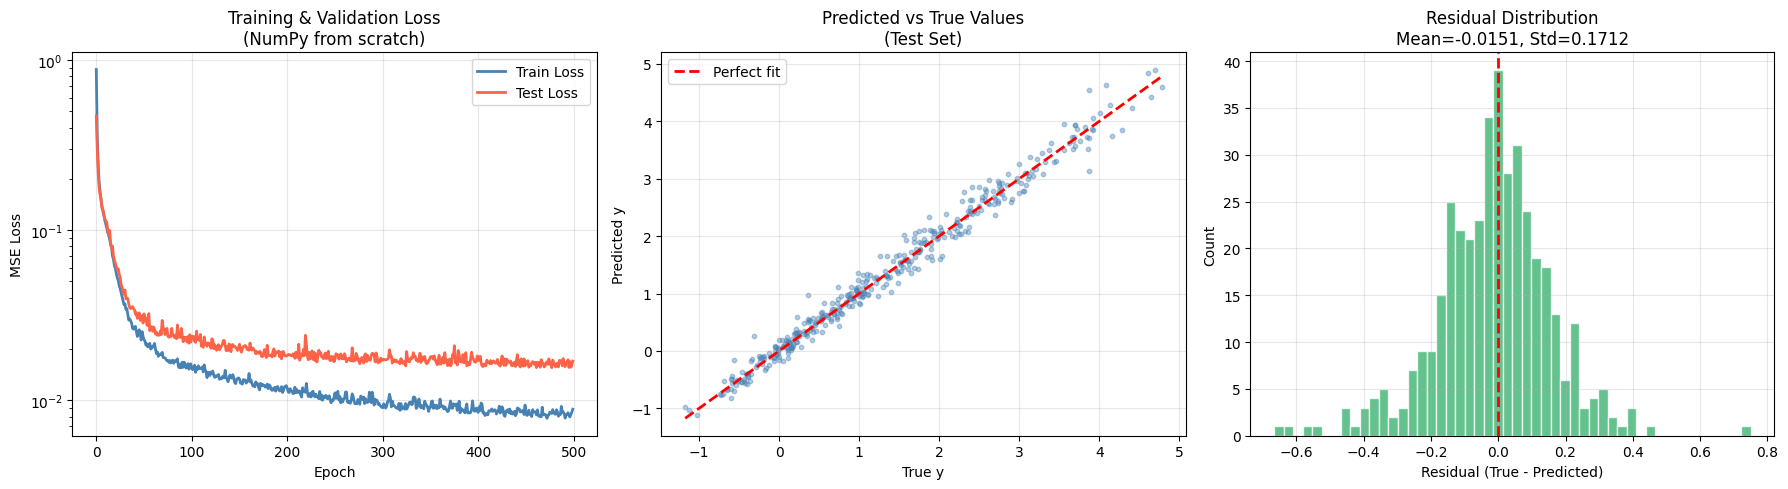

FINAL TEST METRICS (Colab A - NumPy)
R² Score : 0.9828  (1.0 = perfect)
MAE      : 0.1272
MSE      : 0.0295
RMSE     : 0.1718


In [10]:
# ─────────────────────────────────────────────
# SECTION 10: Training Results & Plots
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Loss curve ────────────────────────
ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
ax.plot(history['test_loss'],  label='Test Loss',  color='tomato',    linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss\n(NumPy from scratch)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # log scale shows convergence better

# ── Plot 2: Predicted vs Actual ───────────────
ax = axes[1]
y_final_pred, _ = forward_pass(X_test, trained_params)
y_true_orig = y_test * y_std + y_mean
y_pred_orig = y_final_pred * y_std + y_mean  # denormalize

ax.scatter(y_true_orig, y_pred_orig, alpha=0.4, s=10, color='steelblue')
lims = [y_true_orig.min(), y_true_orig.max()]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
ax.set_xlabel('True y')
ax.set_ylabel('Predicted y')
ax.set_title('Predicted vs True Values\n(Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Residuals ─────────────────────────
ax = axes[2]
residuals = (y_true_orig - y_pred_orig).ravel()
ax.hist(residuals, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (True - Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution\nMean={residuals.mean():.4f}, Std={residuals.std():.4f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colab_a_results.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Final metrics ─────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error
r2  = r2_score(y_true_orig, y_pred_orig)
mae = mean_absolute_error(y_true_orig, y_pred_orig)
mse = np.mean(residuals**2)

print('=' * 40)
print('FINAL TEST METRICS (Colab A - NumPy)')
print('=' * 40)
print(f'R² Score : {r2:.4f}  (1.0 = perfect)')
print(f'MAE      : {mae:.4f}')
print(f'MSE      : {mse:.4f}')
print(f'RMSE     : {np.sqrt(mse):.4f}')
print('=' * 40)